In [ ]:
from models.fista_lr import LogisticRegression
from data.loader import load_openml_data, preprocess_data
from data.missing_data import generate_mcar, generate_mar1, generate_mar2, generate_mnar
from models.unlabeled_lr import UnlabeledLogReg, evaluate, run_naive, run_oracle

# --- dane ---
X_raw, y = load_openml_data(data_id=37)
X = preprocess_data(X_raw)

# --- podziały ---
from sklearn.model_selection import train_test_split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp)

# --- mechanizm brakujących danych ---2
y_obs = generate_mnar(X_tr, y_tr)   # pd.Series z -1 dla brakujących

# --- modele ---
m_cne = UnlabeledLogReg(completion="label_prop_cne", measure="roc_auc")
m_cne.fit(X_tr, y_obs, X_val, y_val)

m_sp = UnlabeledLogReg(completion="sportisse_em", measure="roc_auc")
m_sp.fit(X_tr, y_obs, X_val, y_val)

# --- benchmarki ---
res_naive  = run_naive(X_tr, y_obs, X_val, y_val, X_te, y_te)
res_oracle = run_oracle(X_tr, y_tr, X_val, y_val, X_te, y_te)
res_cne    = evaluate(y_te, m_cne.predict_proba(X_te))
res_sp     = evaluate(y_te, m_sp.predict_proba(X_te))

In [2]:
res_cne

{'accuracy': 0.6428571428571429,
 'balanced_accuracy': 0.495,
 'f1': 0.0,
 'roc_auc': 0.5805555555555556}

In [3]:
res_sp

{'accuracy': 0.6363636363636364,
 'balanced_accuracy': 0.5198148148148148,
 'f1': 0.2,
 'roc_auc': 0.4211111111111111}

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split

# Importy Twoich modułów
from models.fista_lr import LogisticRegression
from data.loader import load_openml_data, preprocess_data
from data.missing_data import generate_mcar, generate_mar1, generate_mar2, generate_mnar
from models.unlabeled_lr import UnlabeledLogReg, evaluate, run_naive, run_oracle

# Ignorowanie ostrzeżeń o braku zbieżności (częste przy Lasso i małej ilości danych)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- KONFIGURACJA ---
np.random.seed(42)

datasets_config = {
    "Spambase": {"id": 44},
    "Musk V2": {"id": 46615},
    "telescope": {"id": 1120},
    "Madelon": {"id": 1485}
}

# Definicja mechanizmów brakujących danych [cite: 31, 32, 33, 34]
mechanisms = {
    "MCAR": lambda X, y: generate_mcar(X, y, c=0.3),
    "MAR1": lambda X, y: generate_mar1(X, y),
    "MAR2": lambda X, y: generate_mar2(X, y),
    "MNAR": lambda X, y: generate_mnar(X, y)
}

all_results = []

print("🚀 Rozpoczynam eksperymenty dla Zadania 3...")

for ds_name, config in datasets_config.items():
    print(f"\n--- Przetwarzanie zbioru: {ds_name} ---")
    
    # 1. Ładowanie i wstępne przygotowanie danych [cite: 19, 24]
    X_raw, y_raw = load_openml_data(config["id"])
    X = preprocess_data(X_raw)
    
    # 2. Podział na Train (60%), Valid (20%), Test (20%) [cite: 39, 74]
    # Ważne: Braki generujemy tylko w zbiorze treningowym [cite: 74]
    X_train, X_temp, y_train, y_temp = train_test_split(X, y_raw, test_size=0.4, stratify=y_raw)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp)
    
    for mech_name, mech_func in mechanisms.items():
        print(f"  > Mechanizm: {mech_name}")
        
        # 3. Generowanie brakujących etykiet (Y_obs) [cite: 27, 29]
        y_obs = mech_func(X_train, y_train)
        
        # --- MODELE ---

        # A. ORACLE: Zna wszystkie prawdziwe etykiety (Benchmark górny) 
        res_oracle = run_oracle(X_train, y_train, X_valid, y_valid, X_test, y_test, measure="roc_auc")
        res_oracle["Method"] = "Oracle"
        
        # B. NAIVE: Trenuje tylko na dostępnych (S=0) 
        res_naive = run_naive(X_train, y_obs, X_valid, y_valid, X_test, y_test, measure="roc_auc")
        res_naive["Method"] = "Naive"
        
        # C. CNe: Label Propagation + Class-Mass Normalisation [cite: 58, 61]
        m_cne = UnlabeledLogReg(completion="label_prop_cne", measure="roc_auc")
        m_cne.fit(X_train, y_obs, X_valid, y_valid)
        res_cne = evaluate(y_test, m_cne.predict_proba(X_test))
        res_cne["Method"] = "Unlabeled (CNe)"
        
        # D. Sportisse EM: EM z estymacją mechanizmu MNAR [cite: 58, 61]
        m_sp = UnlabeledLogReg(completion="sportisse_em", measure="roc_auc")
        m_sp.fit(X_train, y_obs, X_valid, y_valid)
        res_sp = evaluate(y_test, m_sp.predict_proba(X_test))
        res_sp["Method"] = "Unlabeled (Sportisse EM)"
        
        # Zbieranie wyników 
        for res in [res_oracle, res_naive, res_cne, res_sp]:
            res["Dataset"] = ds_name
            res["Mechanism"] = mech_name
            res["Missing_Ratio"] = (y_obs == -1).mean()
            all_results.append(res)

# --- ANALIZA WYNIKÓW ---
df_results = pd.DataFrame(all_results)

# Formatowanie tabeli dla lepszej czytelności
pivot_results = df_results.pivot_table(
    index=["Dataset", "Mechanism", "Method"], 
    values=["accuracy", "balanced_accuracy", "f1", "roc_auc"]
)

print("\n✅ Eksperyment zakończony!")
display(pivot_results)

# Opcjonalnie: Eksport do CSV do raportu
df_results.to_csv("task3_results2.csv", index=False)

🚀 Rozpoczynam eksperymenty dla Zadania 3...

--- Przetwarzanie zbioru: Spambase ---
  > Mechanizm: MCAR
  > Mechanizm: MAR1
  > Mechanizm: MAR2
  > Mechanizm: MNAR

--- Przetwarzanie zbioru: Musk V2 ---
  > Mechanizm: MCAR
  > Mechanizm: MAR1
  > Mechanizm: MAR2
  > Mechanizm: MNAR

--- Przetwarzanie zbioru: telescope ---
  > Mechanizm: MCAR
  > Mechanizm: MAR1
  > Mechanizm: MAR2
  > Mechanizm: MNAR

--- Przetwarzanie zbioru: Madelon ---
  > Mechanizm: MCAR
  > Mechanizm: MAR1
  > Mechanizm: MAR2
  > Mechanizm: MNAR

✅ Eksperyment zakończony!


accuracy  balanced_accuracy  \
Dataset   Mechanism Method                                                  
Madelon   MAR1      Naive                     0.571154           0.571154   
                    Oracle                    0.623077           0.623077   
                    Unlabeled (CNe)           0.523077           0.523077   
                    Unlabeled (Sportisse EM)  0.546154           0.546154   
          MAR2      Naive                     0.598077           0.598077   
...                                                ...                ...   
telescope MCAR      Unlabeled (Sportisse EM)  0.789432           0.752295   
          MNAR      Naive                     0.758938           0.765526   
                    Oracle                    0.786278           0.738238   
                    Unlabeled (CNe)           0.351735           0.500000   
                    Unlabeled (Sportisse EM)  0.648791           0.500747   

                                                    f1   roc_auc  
Dataset   Mechanism Method                                        
Madelon   MAR1      Naive                     0.580038  0.590503  
                    Oracle                    0.618677  0.645851  
                    Unlabeled (CNe)           0.210191  0.579112  
                    Unlabeled (Sportisse EM)  0.674033  0.563180  
          MAR2      Naive                     0.628774  0.645851  
...                                                ...       ...  
telescope MCAR      Unlabeled (Sportisse EM)  0.843829  0.829232  
          MNAR      Naive                     0.799913  0.833909  
                    Oracle                    0.845231  0.828979  
                    Unlabeled (CNe)           0.000000  0.825145  
                    Unlabeled (Sportisse EM)  0.786854  0.823141  

[64 rows x 4 columns]

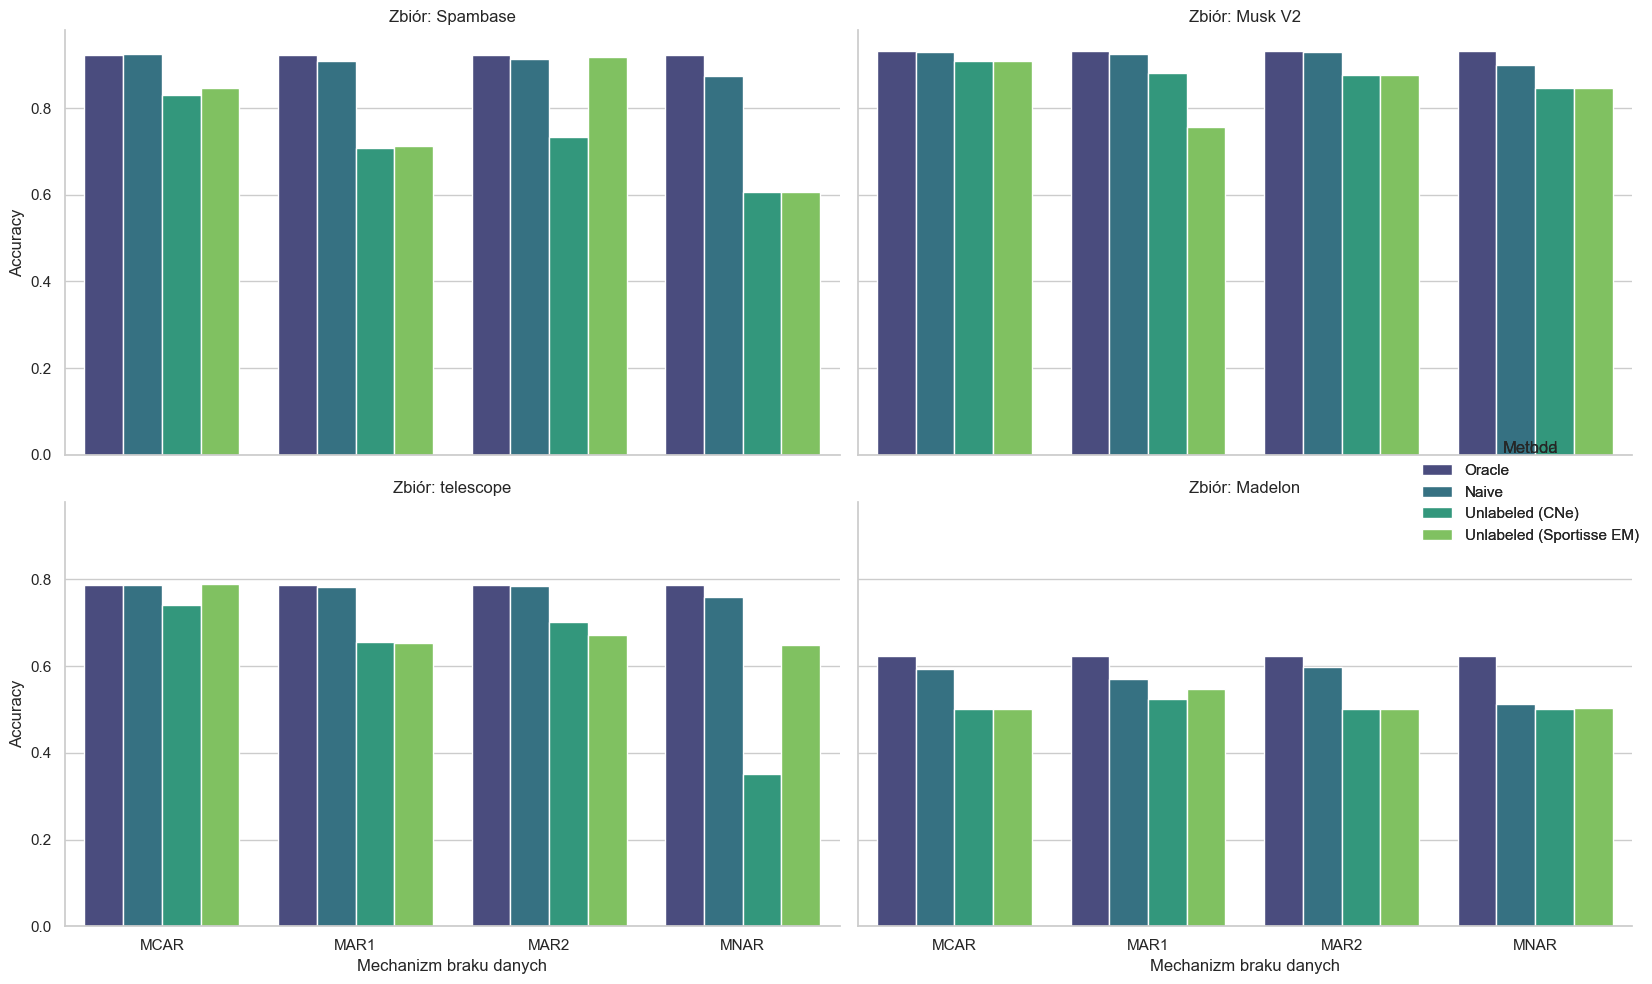

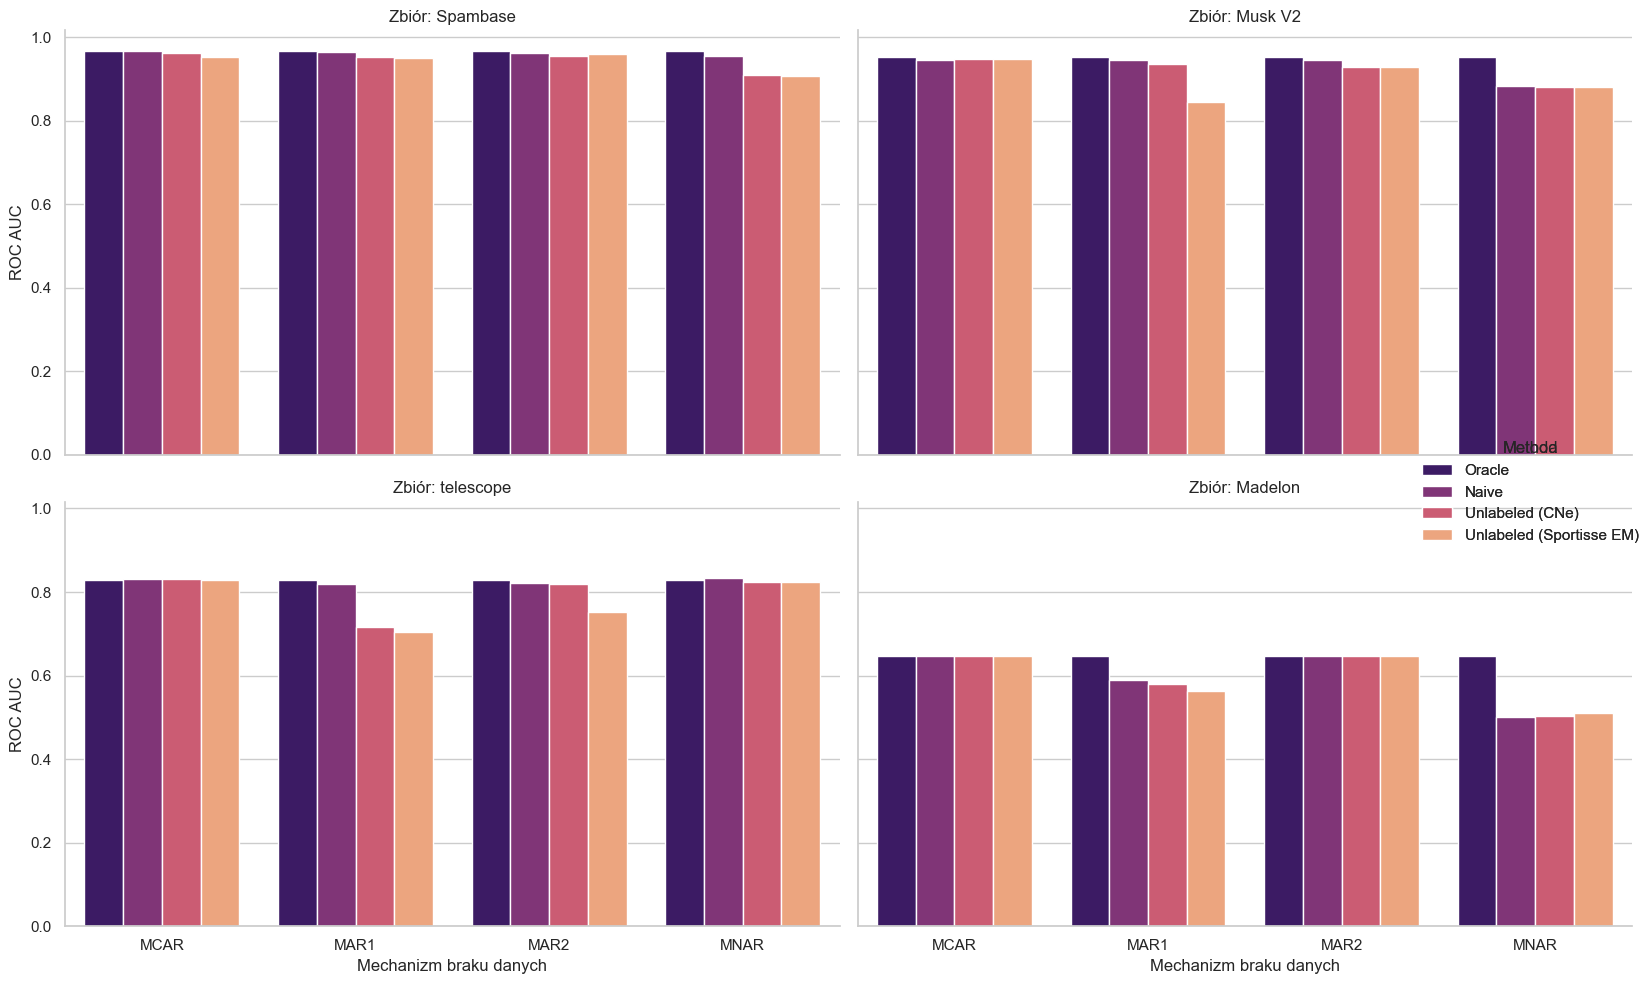

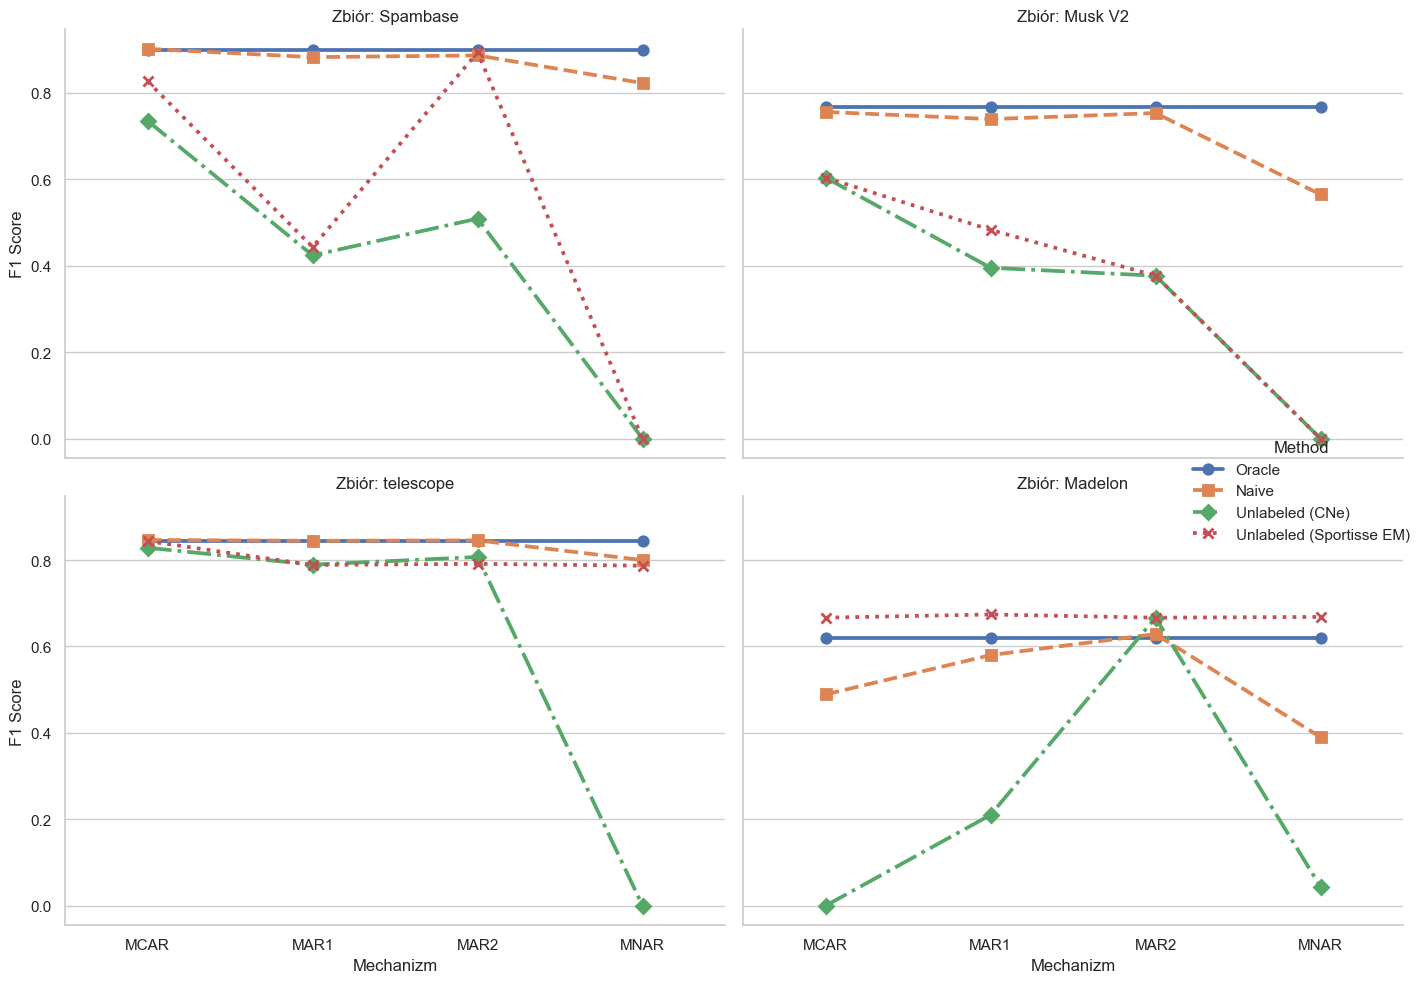

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Wczytanie danych z pliku
df = pd.read_csv('task3_results2.csv')

# Ustawienie estetycznego stylu wykresów
sns.set_theme(style="whitegrid")

# --- WYKRES 1: Accuracy (Dokładność) ---
# Porównujemy metody wewnątrz każdego mechanizmu braków, 
# tworząc oddzielny panel dla każdego zbioru danych.
g1 = sns.catplot(
    data=df, kind="bar",
    x="Mechanism", y="accuracy", hue="Method",
    col="Dataset", col_wrap=2,
    palette="viridis", height=5, aspect=1.2
)
g1.set_axis_labels("Mechanizm braku danych", "Accuracy")
g1.set_titles("Zbiór: {col_name}")
g1.add_legend(title="Metoda")
plt.tight_layout()
plt.savefig('comparison_accuracy.png')

# --- WYKRES 2: ROC AUC ---
# ROC AUC jest kluczowy, by sprawdzić, czy model poprawnie rankuje 
# prawdopodobieństwa, co jest ważne przy braku balansu klas.
g2 = sns.catplot(
    data=df, kind="bar",
    x="Mechanism", y="roc_auc", hue="Method",
    col="Dataset", col_wrap=2,
    palette="magma", height=5, aspect=1.2
)
g2.set_axis_labels("Mechanizm braku danych", "ROC AUC")
g2.set_titles("Zbiór: {col_name}")
g2.add_legend(title="Metoda")
plt.tight_layout()
plt.savefig('comparison_roc_auc.png')

# --- WYKRES 3: F1-Score (Wykres punktowy) ---
# Wykres punktowy (pointplot) lepiej pokazuje trendy i spadki wydajności
# metod SSL względem Oracle przy trudniejszych mechanizmach (np. MNAR).
g3 = sns.catplot(
    data=df, kind="point",
    x="Mechanism", y="f1", hue="Method",
    col="Dataset", col_wrap=2,
    markers=["o", "s", "D", "x"], 
    linestyles=["-", "--", "-.", ":"],
    height=5, aspect=1.2
)
g3.set_axis_labels("Mechanizm", "F1 Score")
g3.set_titles("Zbiór: {col_name}")
plt.tight_layout()
plt.savefig('comparison_f1_score.png')

In [4]:
pivot_results

accuracy  balanced_accuracy  \
Dataset  Mechanism Method                                                  
Isolet   MAR1      Naive                     1.000000           1.000000   
                   Oracle                    1.000000           1.000000   
                   Unlabeled (CNe)           0.991667           0.991667   
                   Unlabeled (Sportisse EM)  0.991667           0.991667   
         MAR2      Naive                     1.000000           1.000000   
...                                               ...                ...   
Spambase MCAR      Unlabeled (Sportisse EM)  0.826276           0.785391   
         MNAR      Naive                     0.840391           0.806666   
                   Oracle                    0.921824           0.915748   
                   Unlabeled (CNe)           0.605863           0.500000   
                   Unlabeled (Sportisse EM)  0.605863           0.500000   

                                                   f1   roc_auc  
Dataset  Mechanism Method                                        
Isolet   MAR1      Naive                     1.000000  1.000000  
                   Oracle                    1.000000  1.000000  
                   Unlabeled (CNe)           0.991736  1.000000  
                   Unlabeled (Sportisse EM)  0.991597  1.000000  
         MAR2      Naive                     1.000000  1.000000  
...                                               ...       ...  
Spambase MCAR      Unlabeled (Sportisse EM)  0.728814  0.959932  
         MNAR      Naive                     0.761750  0.945195  
                   Oracle                    0.899441  0.967722  
                   Unlabeled (CNe)           0.000000  0.923146  
                   Unlabeled (Sportisse EM)  0.000000  0.902206  

[64 rows x 4 columns]

In [7]:
pd.set_option('display.max_rows', None)
df_results

,accuracy,balanced_accuracy,f1,roc_auc,Method,Dataset,Mechanism,Missing_Ratio
0,0.921824,0.915748,0.899441,0.967722,Oracle,Spambase,MCAR,0.307971
1,0.923996,0.917541,0.901961,0.966014,Naive,Spambase,MCAR,0.307971
2,0.829533,0.789523,0.735245,0.962410,Unlabeled (CNe),Spambase,MCAR,0.307971
3,0.826276,0.785391,0.728814,0.959932,Unlabeled (Sportisse EM),Spambase,MCAR,0.307971
4,0.921824,0.915748,0.899441,0.967722,Oracle,Spambase,MAR1,0.480797
5,0.908795,0.902108,0.882682,0.964962,Naive,Spambase,MAR1,0.480797
6,0.707926,0.631883,0.423983,0.951445,Unlabeled (CNe),Spambase,MAR1,0.480797
7,0.713355,0.639252,0.443038,0.948843,Unlabeled (Sportisse EM),Spambase,MAR1,0.480797
8,0.921824,0.915748,0.899441,0.967722,Oracle,Spambase,MAR2,0.407609
9,0.912052,0.905277,0.886713,0.962647,Naive,Spambase,MAR2,0.407609
